### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import os
import missingno
import joblib
from datasist.structdata import detect_outliers
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn_features.transformers import DataFrameSelector
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,confusion_matrix,r2_score
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor

### `Read Dataset`

In [2]:
File_Path = os.path.join(os.getcwd(),'avocado.csv')
df = pd.read_csv(File_Path)
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


### `Data Analysis`

In [3]:
df.columns = df.columns.str.replace(' ', '_')
df.columns=df.columns.str.lower()

In [4]:
# Renaming columns
df.rename(columns={'4046': 'plus_4046', '4225': 'plus_4225', '4770': 'plus_4770'}, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unnamed:_0    18249 non-null  int64  
 1   date          18249 non-null  object 
 2   averageprice  18249 non-null  float64
 3   total_volume  18249 non-null  float64
 4   plus_4046     18249 non-null  float64
 5   plus_4225     18249 non-null  float64
 6   plus_4770     18249 non-null  float64
 7   total_bags    18249 non-null  float64
 8   small_bags    18249 non-null  float64
 9   large_bags    18249 non-null  float64
 10  xlarge_bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [6]:
df.describe()

,unnamed:_0,averageprice,total_volume,plus_4046,plus_4225,plus_4770,total_bags,small_bags,large_bags,xlarge_bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [7]:
df.shape

(18249, 14)

In [8]:
df.averageprice.value_counts()

averageprice
1.15    202
1.18    199
1.08    194
1.26    193
1.13    192
       ... 
3.25      1
3.12      1
2.68      1
3.03      1
3.17      1
Name: count, Length: 259, dtype: int64

In [9]:
## to check if there null values
df.apply(lambda x: len(x.isnull()))

unnamed:_0      18249
date            18249
averageprice    18249
total_volume    18249
plus_4046       18249
plus_4225       18249
plus_4770       18249
total_bags      18249
small_bags      18249
large_bags      18249
xlarge_bags     18249
type            18249
year            18249
region          18249
dtype: int64

In [10]:
#check cols that have nulls
cols = pd.DataFrame(df.isna().sum() > 0, columns=['null_or_not'])
cols_with_nulls = cols[cols['null_or_not']].index.to_list()
cols_with_nulls

[]

In [11]:
df[cols_with_nulls]

""
0
1
2
3
4
...
18244
18245
18246
18247


In [12]:
df.isna().sum(axis=0).sort_values(ascending=False)

unnamed:_0      0
date            0
averageprice    0
total_volume    0
plus_4046       0
plus_4225       0
plus_4770       0
total_bags      0
small_bags      0
large_bags      0
xlarge_bags     0
type            0
year            0
region          0
dtype: int64

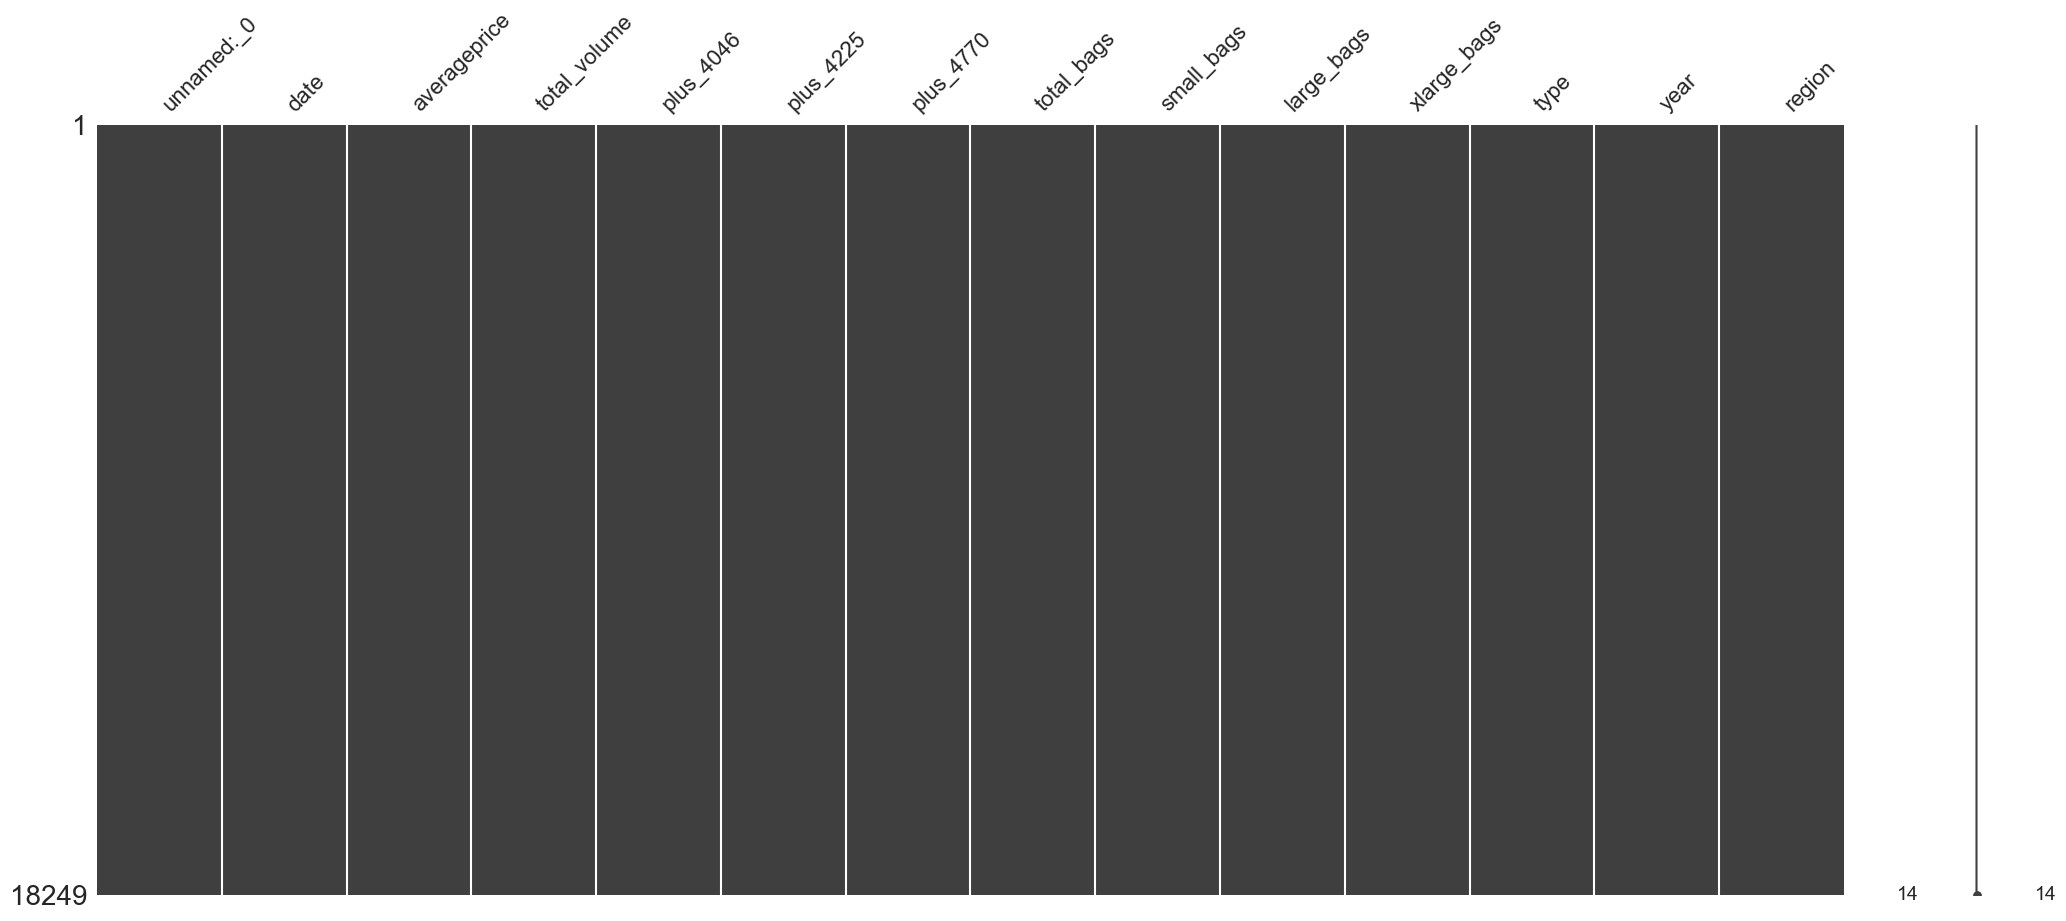

In [13]:
missingno.matrix(df)
plt.show()

In [14]:
# Check duplicates
df.duplicated().sum()

0

In [15]:
# To check if there unique values in Dataset
df.apply(lambda x: len(x.unique()))

unnamed:_0         53
date              169
averageprice      259
total_volume    18237
plus_4046       17702
plus_4225       18103
plus_4770       12071
total_bags      18097
small_bags      17321
large_bags      15082
xlarge_bags      5588
type                2
year                4
region             54
dtype: int64

### `Feature Engineering`

In [16]:
df.drop(['unnamed:_0','date'], axis = 1, inplace = True)

### `EDA`

In [17]:
num_cols = df.select_dtypes(include='number').columns.to_list()
num_cols

['averageprice',
 'total_volume',
 'plus_4046',
 'plus_4225',
 'plus_4770',
 'total_bags',
 'small_bags',
 'large_bags',
 'xlarge_bags',
 'year']

In [18]:
num_cols1 = df.select_dtypes(include='number').columns.tolist()[1:]
num_cols1

['total_volume',
 'plus_4046',
 'plus_4225',
 'plus_4770',
 'total_bags',
 'small_bags',
 'large_bags',
 'xlarge_bags',
 'year']

In [19]:
categ_cols = df.select_dtypes(include='object').columns.tolist()
categ_cols

['type', 'region']

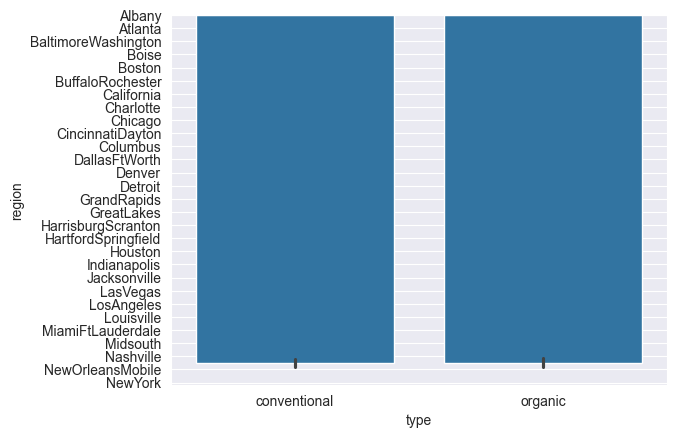

In [20]:
sns.barplot(x='type', y='region', data=df)
plt.show()


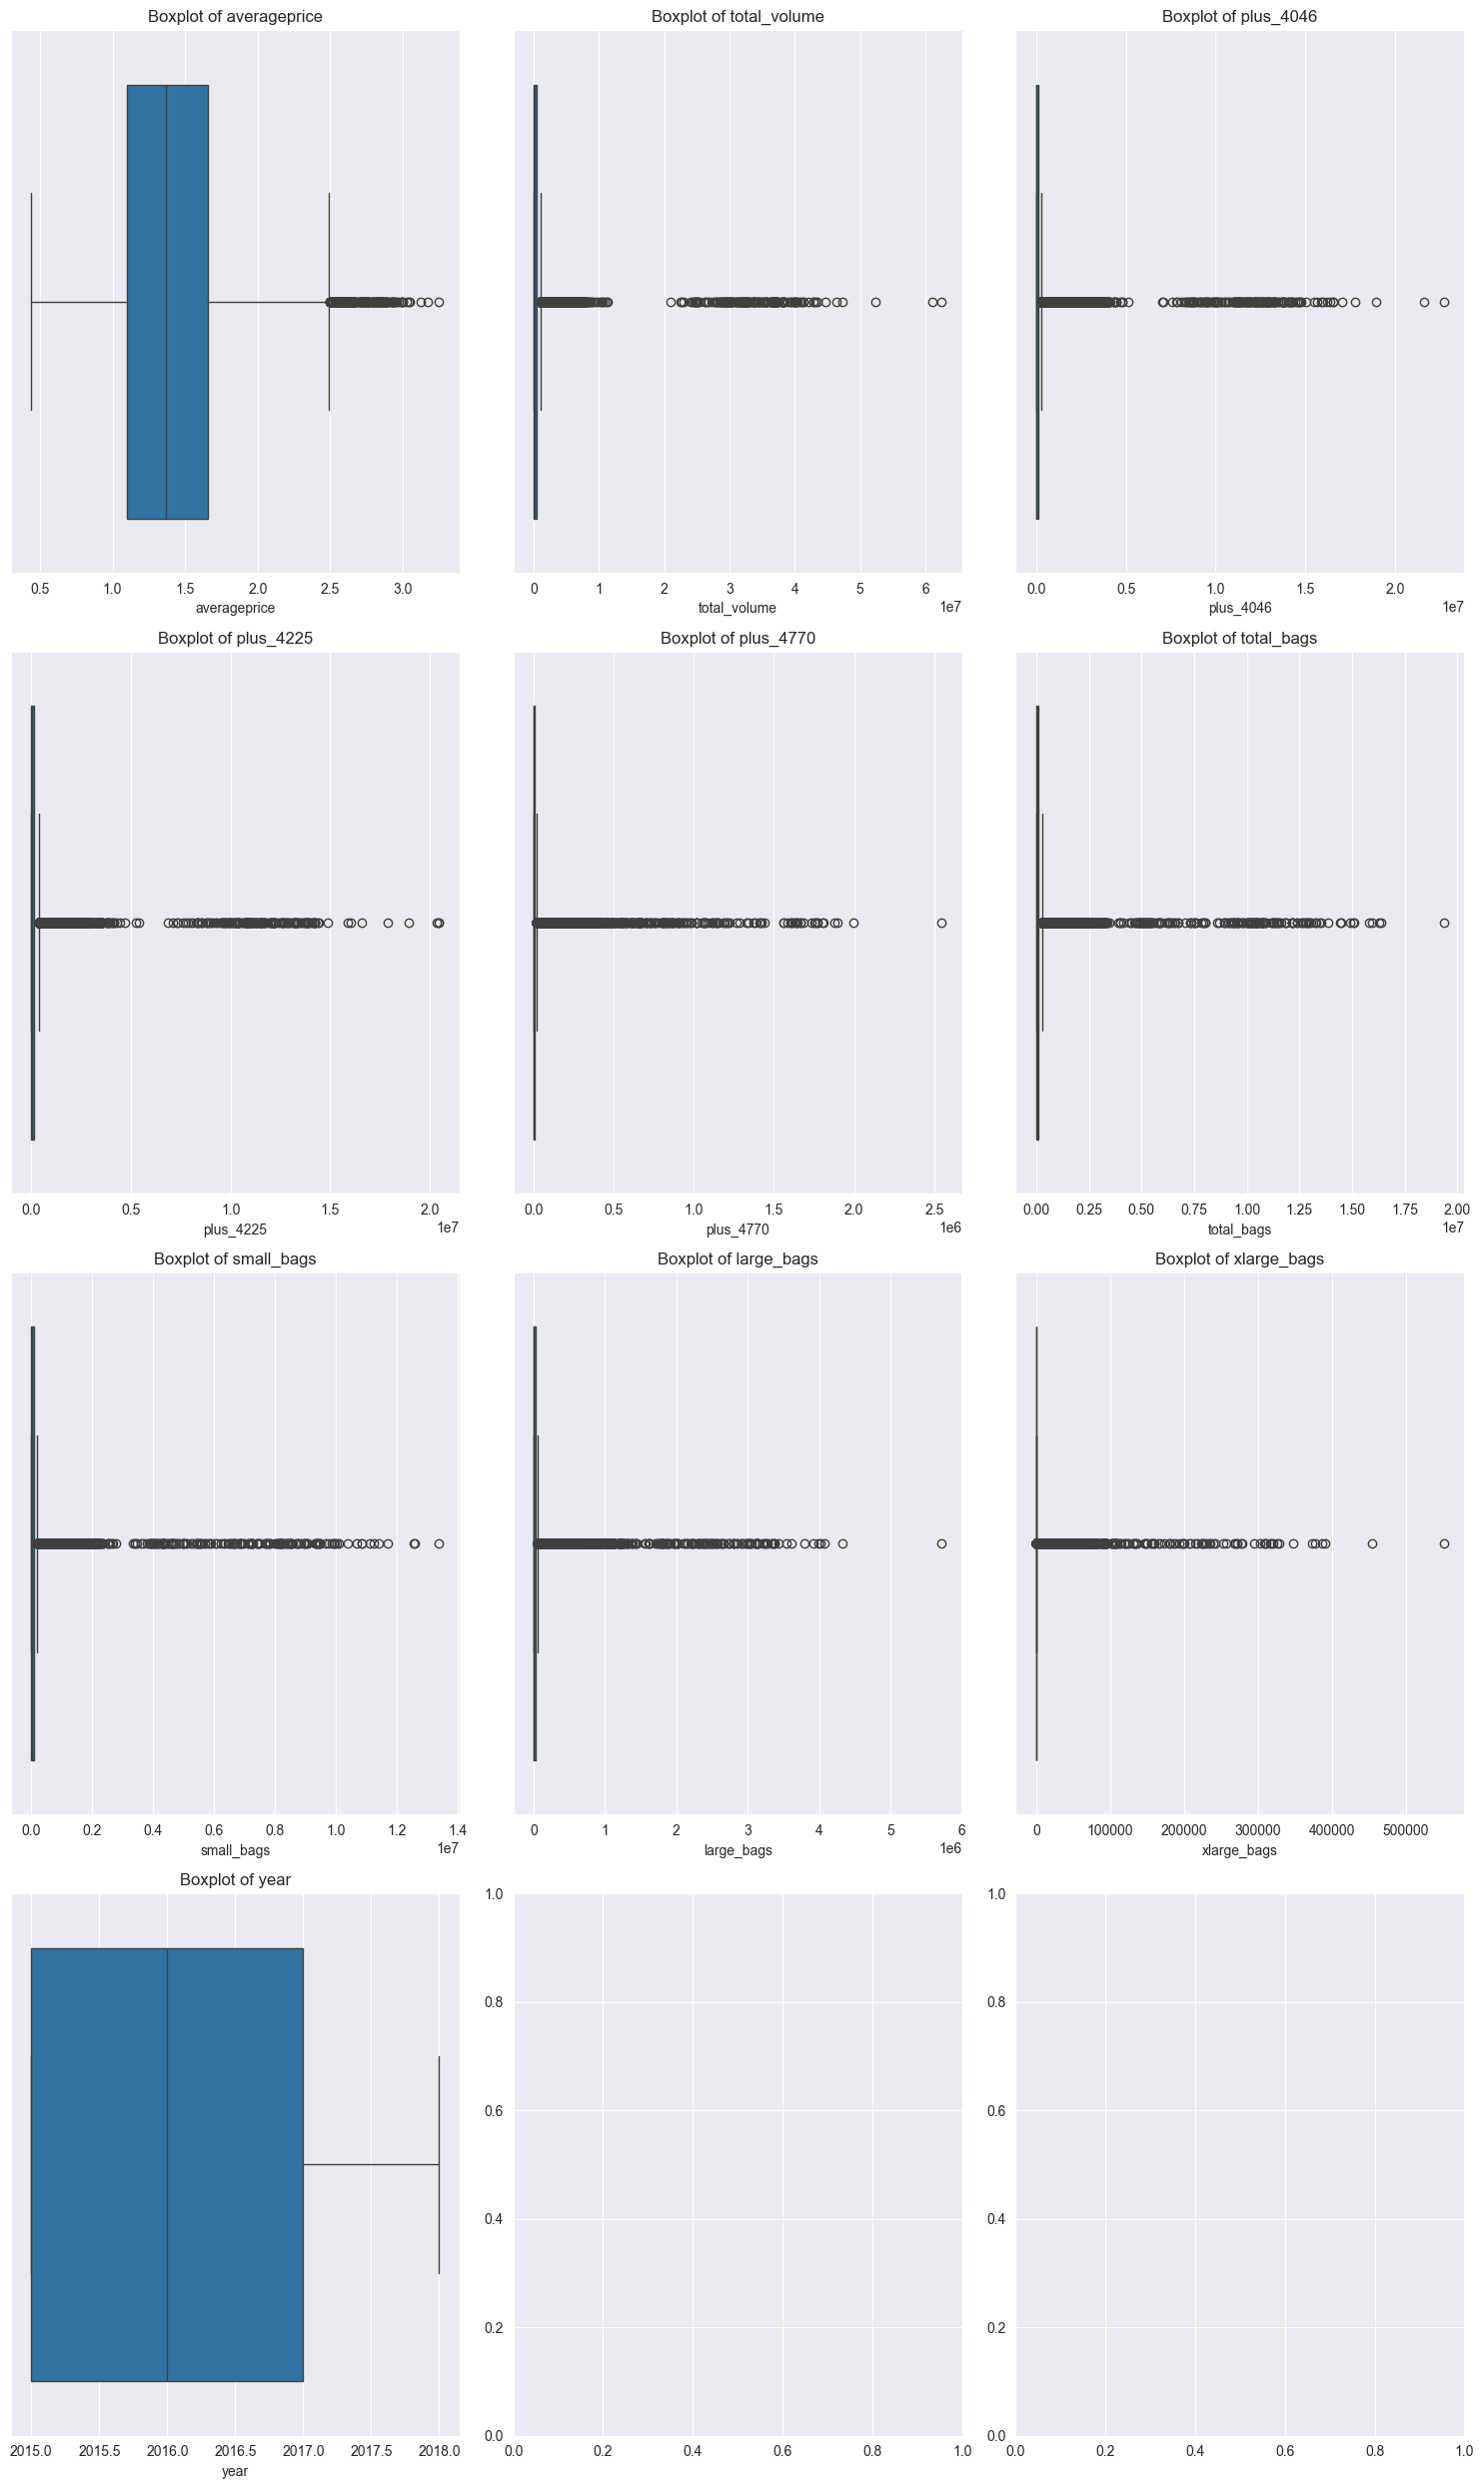

In [21]:
# Create subplots
fig, ax = plt.subplots(4,3, figsize=(15, 25))

# Flatten the axes array
ax = ax.flatten()

# Plot boxplots for each numerical column
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=ax[i])
    ax[i].set_title(f'Boxplot of {col}')
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('')

# Adjust layout
plt.tight_layout()
plt.show()


In [22]:
'''# Plot skewness for each numeric column
plt.figure(figsize=(20, 50))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Skewness of {col}: {df[col].skew()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()'''

"# Plot skewness for each numeric column\nplt.figure(figsize=(20, 50))\nfor i, col in enumerate(num_cols, 1):\n    plt.subplot(5, 2, i)\n    sns.histplot(df[col], kde=True)\n    plt.title(f'Skewness of {col}: {df[col].skew()}')\n    plt.xlabel(col)\n    plt.ylabel('Frequency')\n\nplt.tight_layout()\nplt.show()"

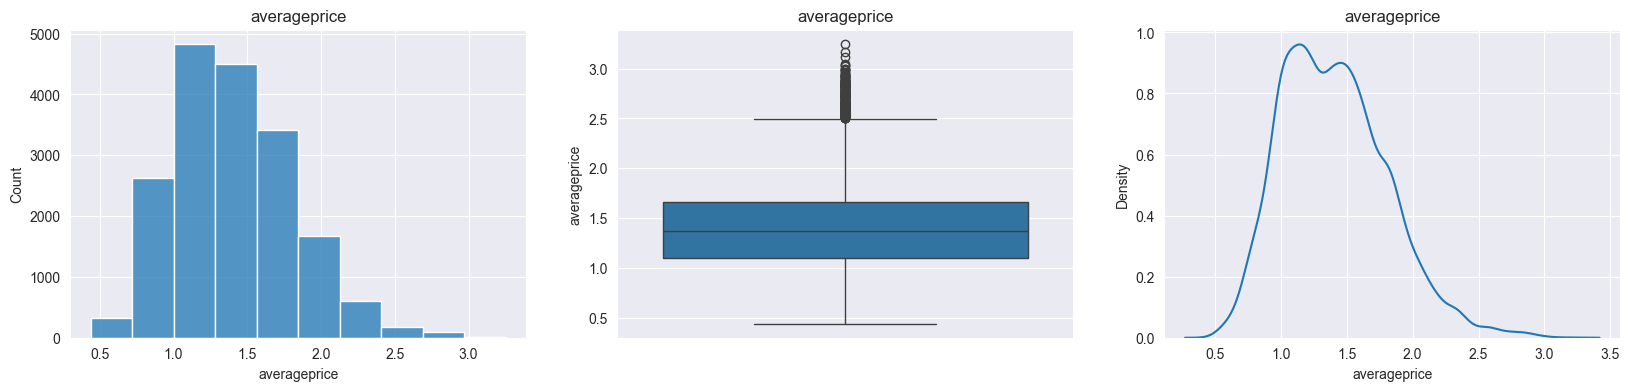

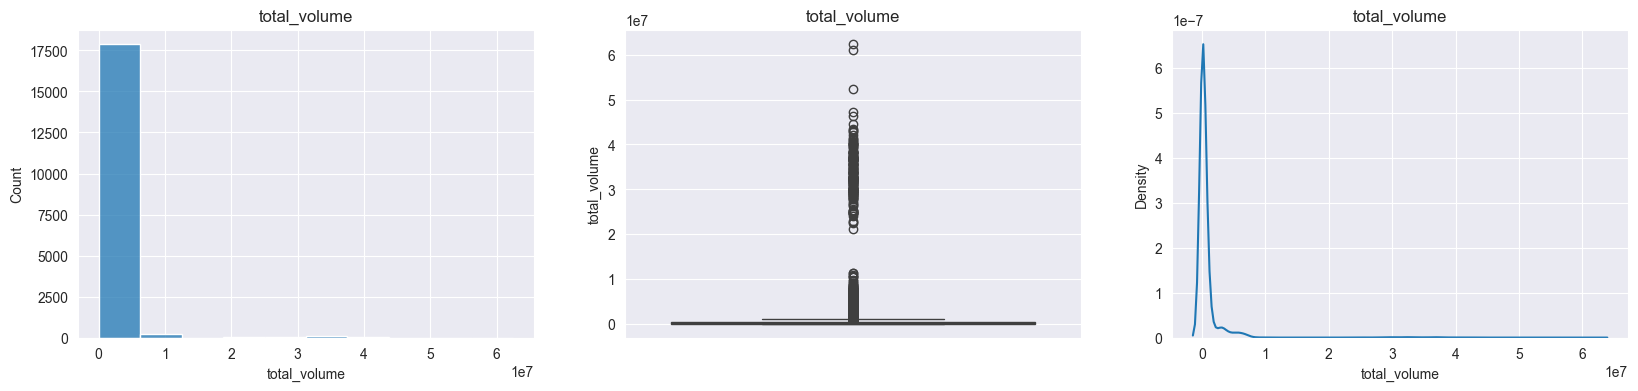

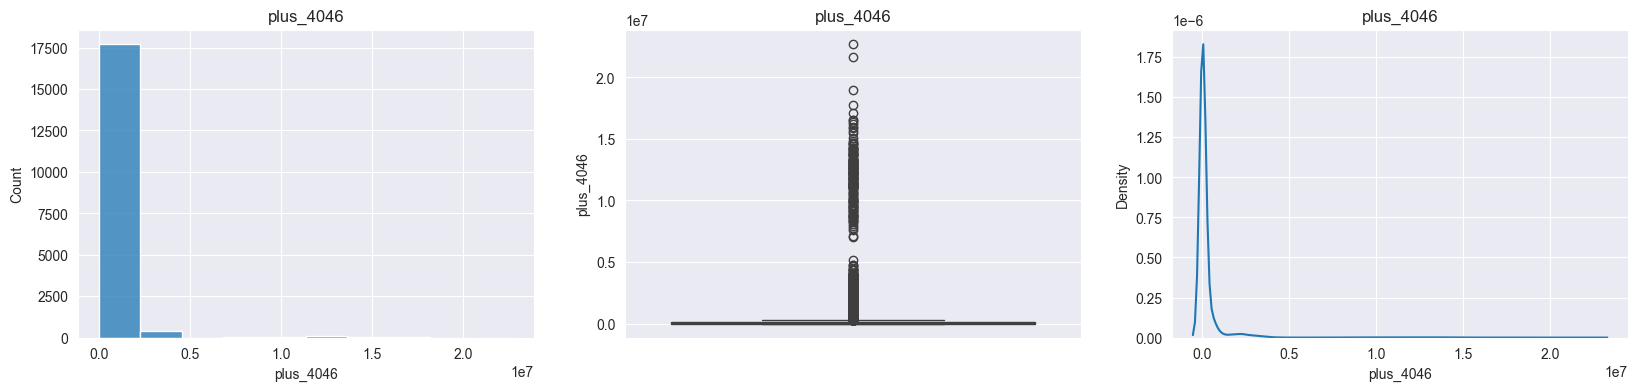

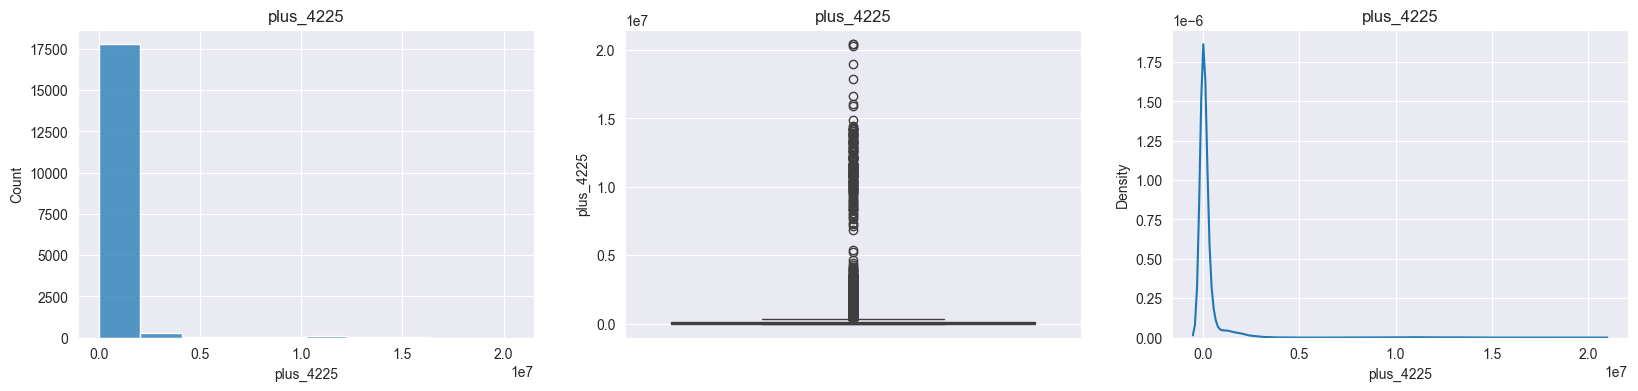

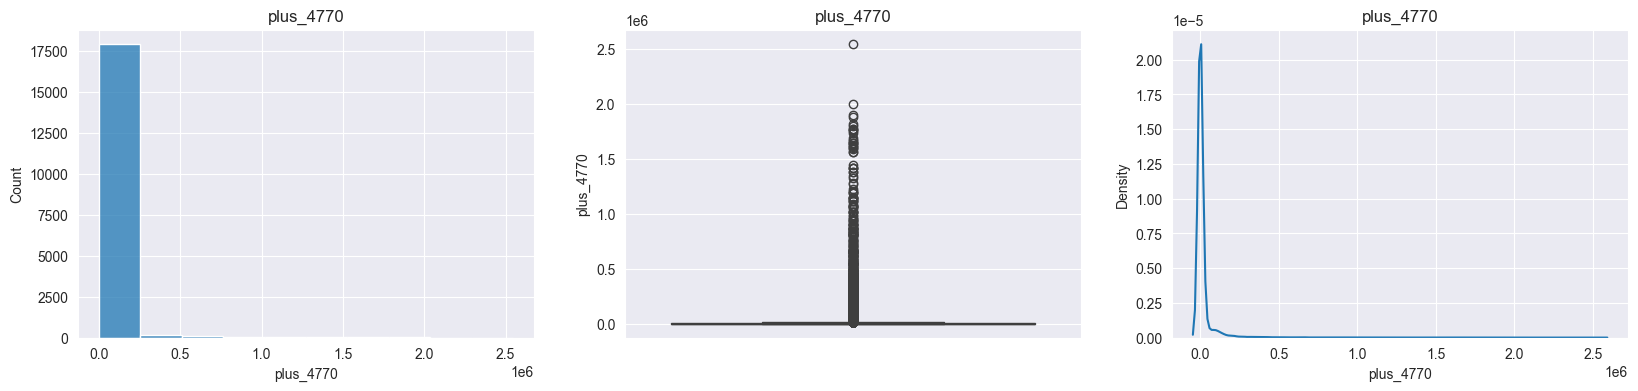

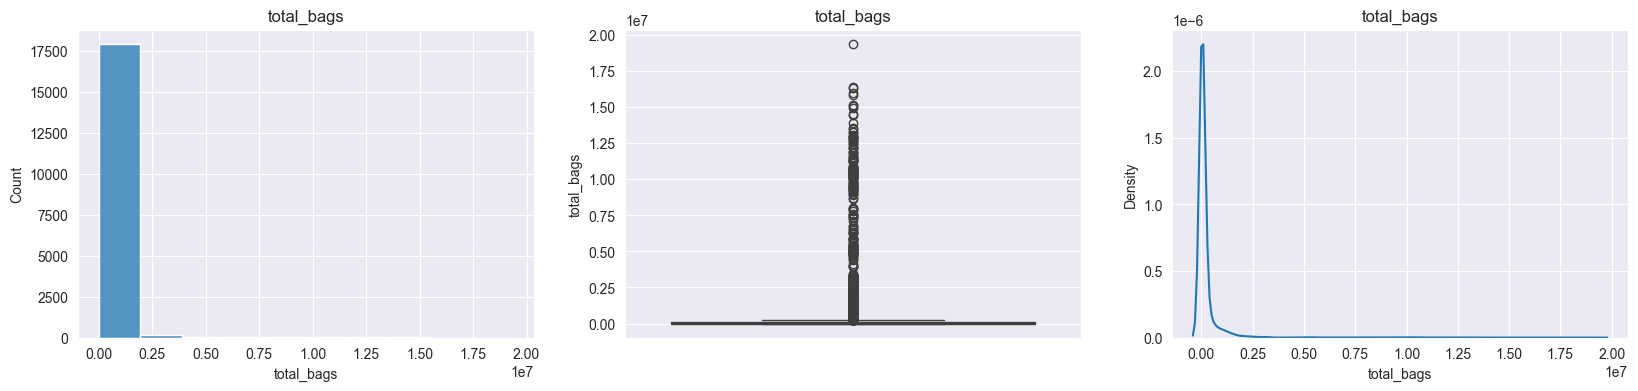

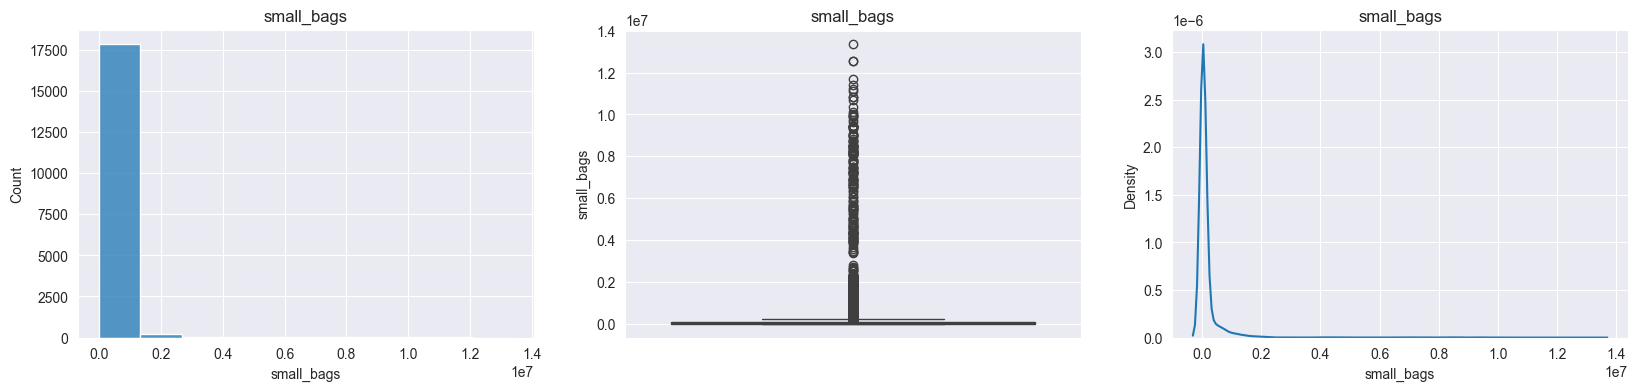

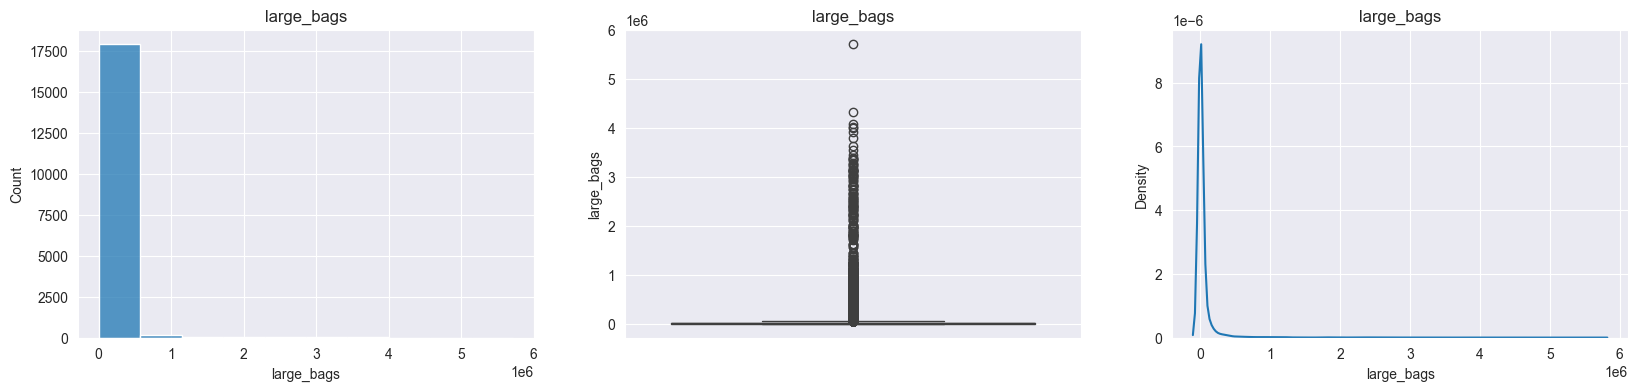

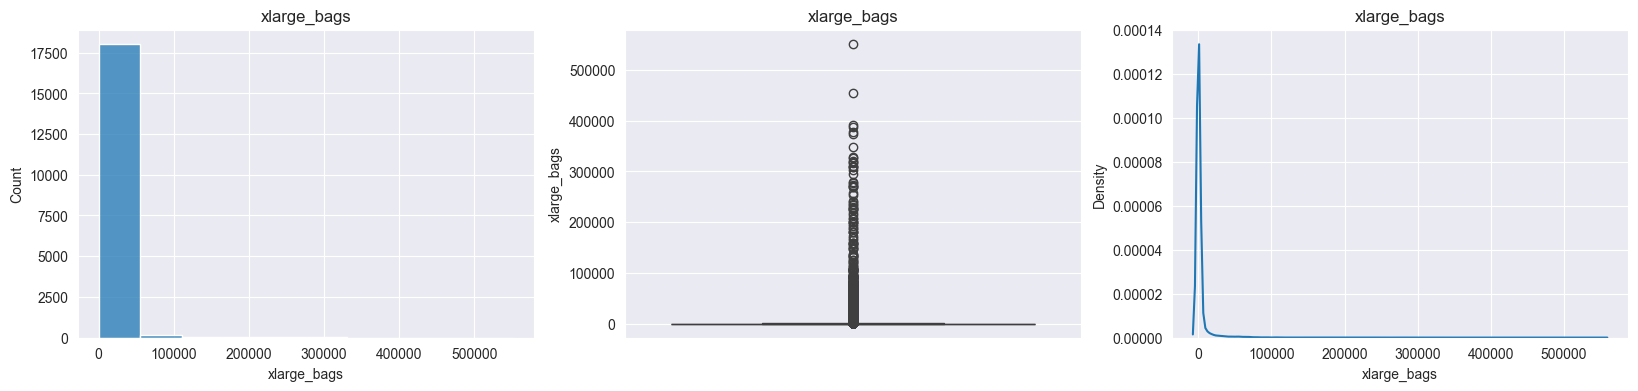

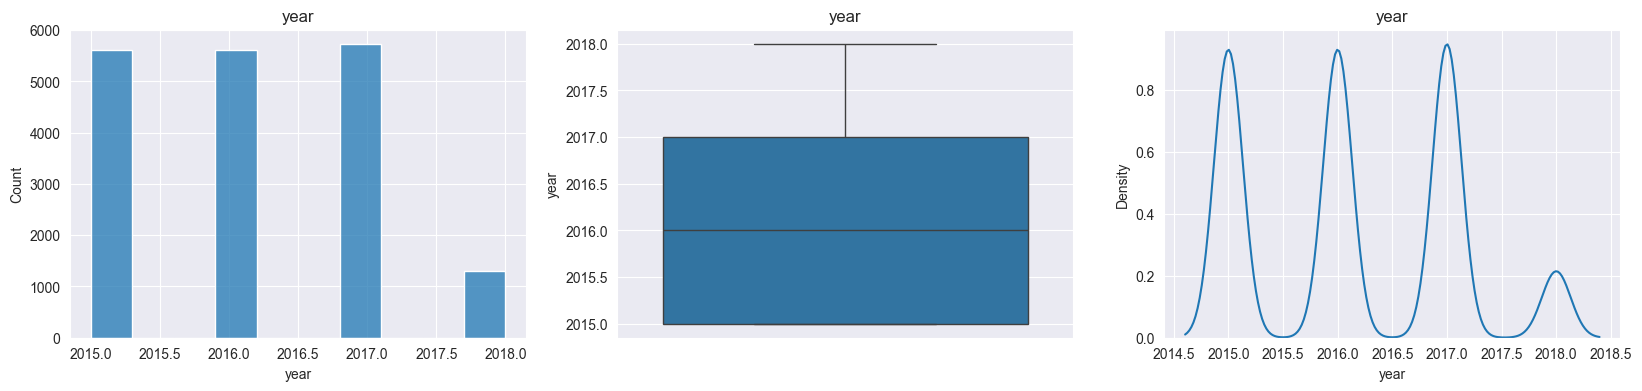

In [23]:
def graph(df):
    num_cols
    for i in num_cols:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))
        
        sns.histplot(x=df[i], bins=10, ax=axes[0])
        axes[0].set_title(i)
        
        sns.boxplot(y=df[i], orient='Horizontal', ax=axes[1])  # Use horizontal orientation
        axes[1].set_title(i)
        
        sns.kdeplot(x=df[i], ax=axes[2], warn_singular=False)
        axes[2].set_title(i)
        
        plt.show()

# Call the function with your DataFrame
graph(df)

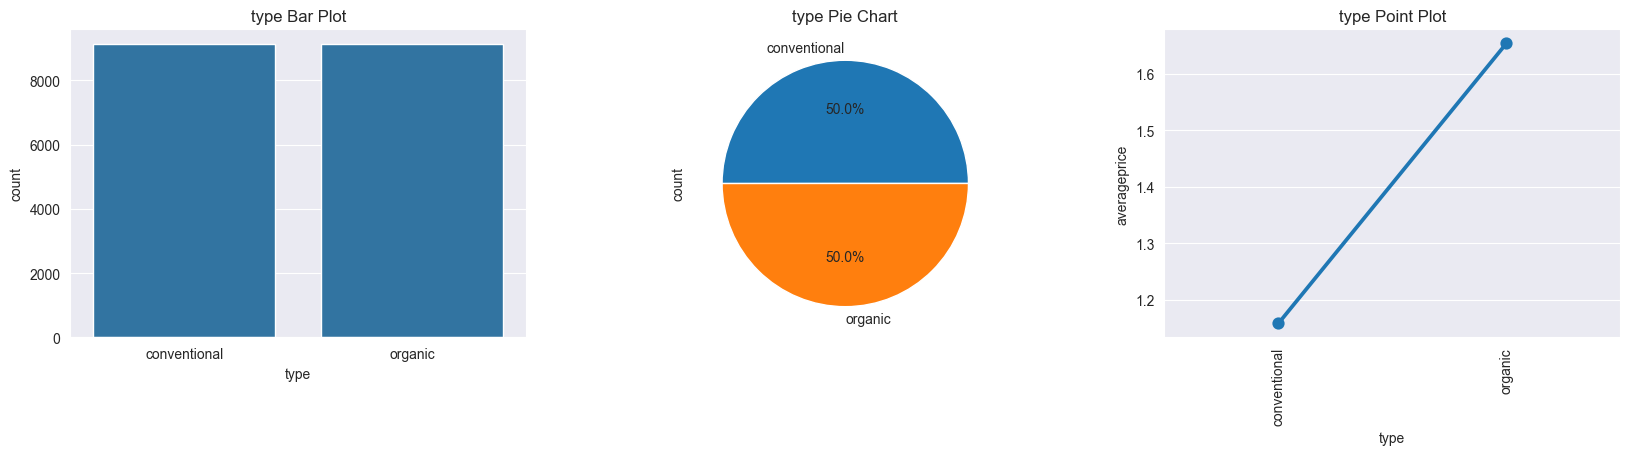

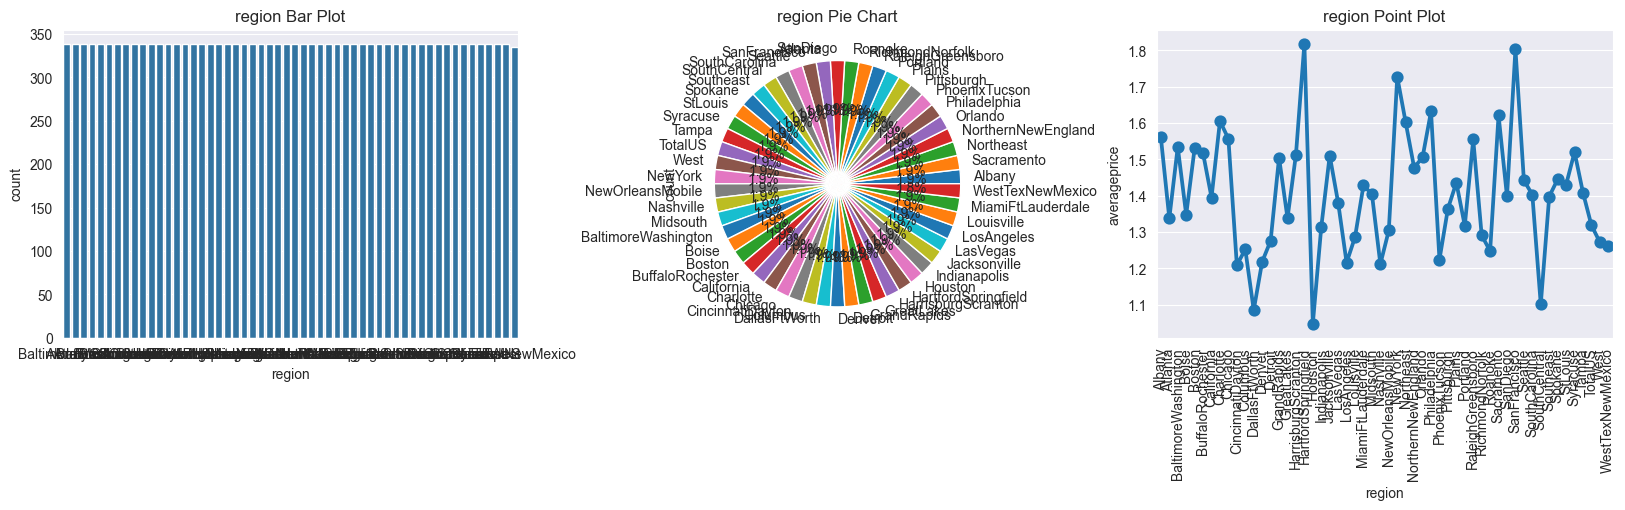

In [24]:
def cat_graph(df):
    categ_cols
    for i in categ_cols:
        # bar plot
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))
        sns.countplot(data=df, x=i, ax=axes[0])  # Modified line
        plt.xticks(rotation=90)
        axes[0].set_title(f'{i} Bar Plot')

        # pie chart
        df[i].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
        plt.ylabel('')
        axes[1].set_title(f'{i} Pie Chart')

        # point plot
        sns.pointplot(data=df, x=i, y='averageprice', errorbar=None, ax=axes[2])  # Modified line
        plt.xticks(rotation=90)
        axes[2].set_title(f'{i} Point Plot')

    plt.show()


cat_graph(df)

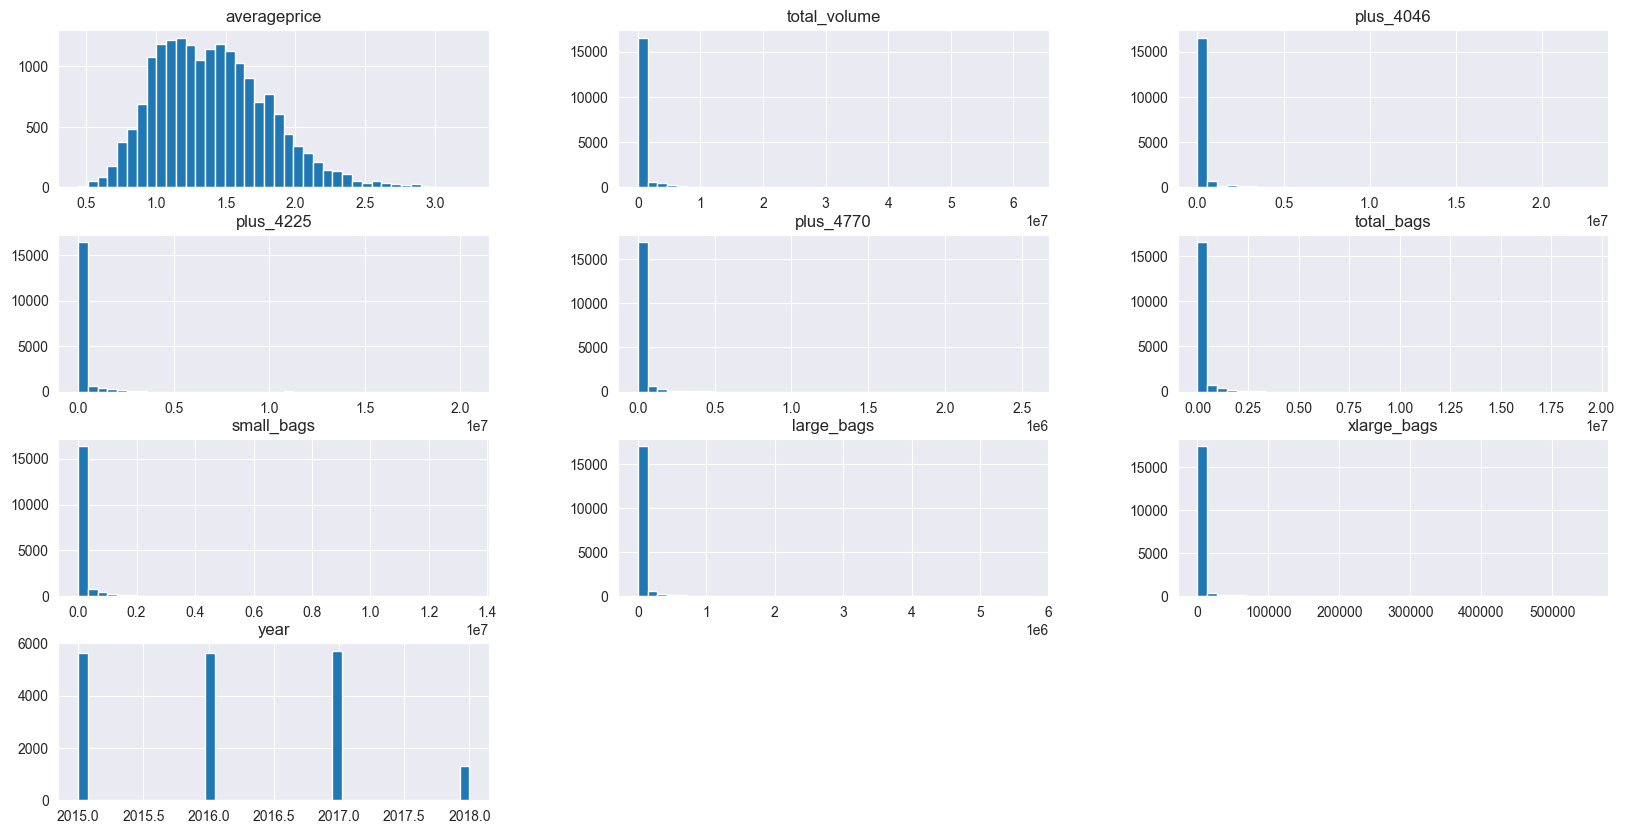

In [25]:
## Check Distribution before handling outliers
df.hist(bins=40, figsize=(20,10))
plt.show()

In [26]:
## Get the Numerical cols firstly
num_cols1 = df.select_dtypes(include='number').columns.tolist()[1:]
num_cols1

for col in num_cols1:
    each_idx = detect_outliers(data=df, n=0, features=[col])
    each_median = df[col].median()

    df.loc[each_idx, col] = each_median

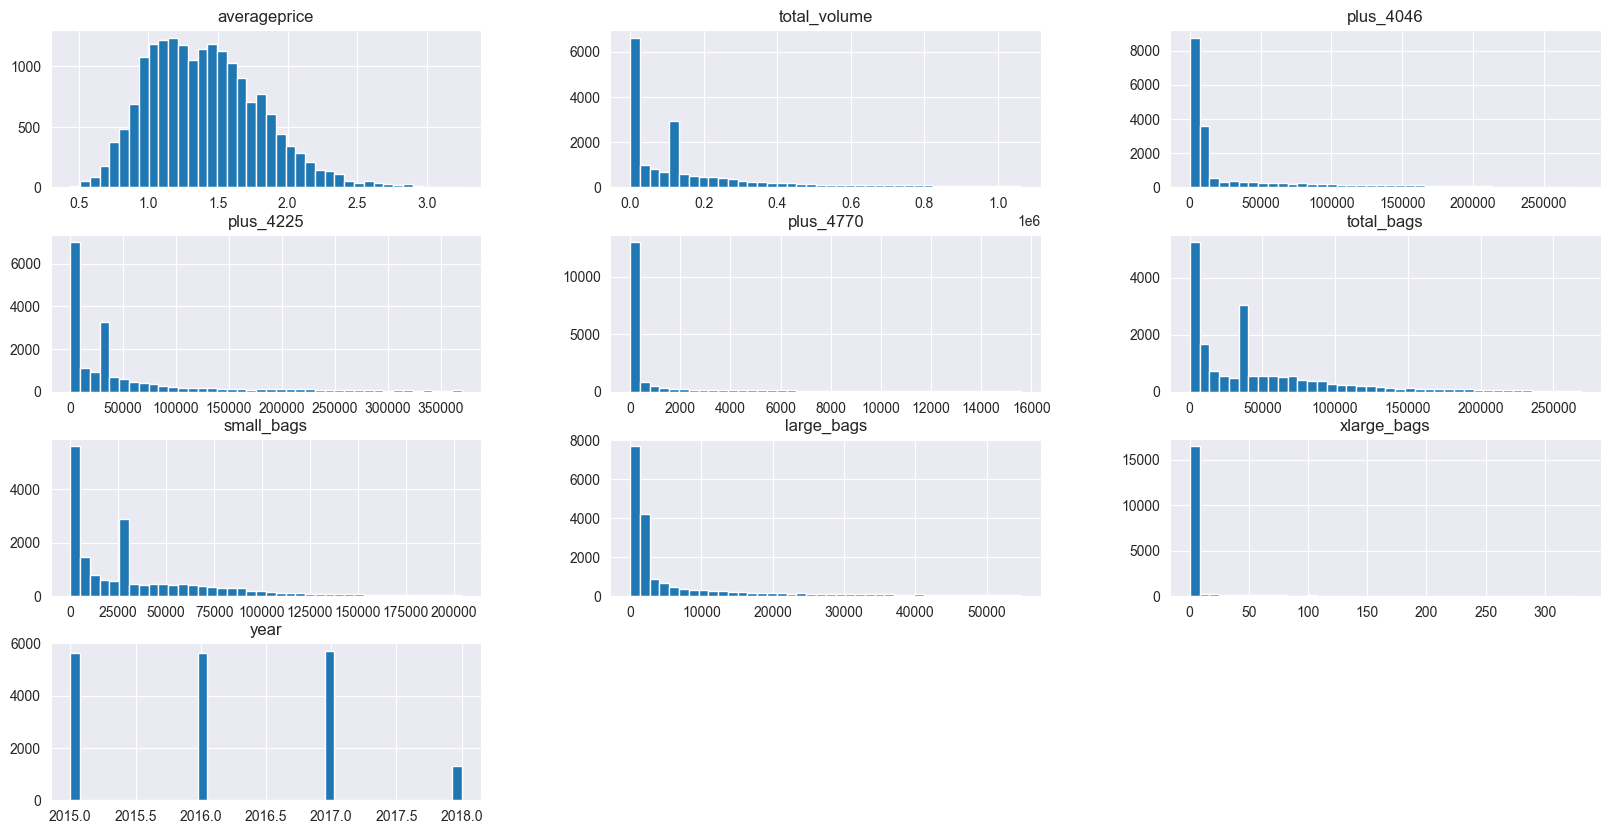

In [27]:
## Check Distribution after handling outliers
df.hist(bins=40, figsize=(20,10))
plt.show()

<Axes: >

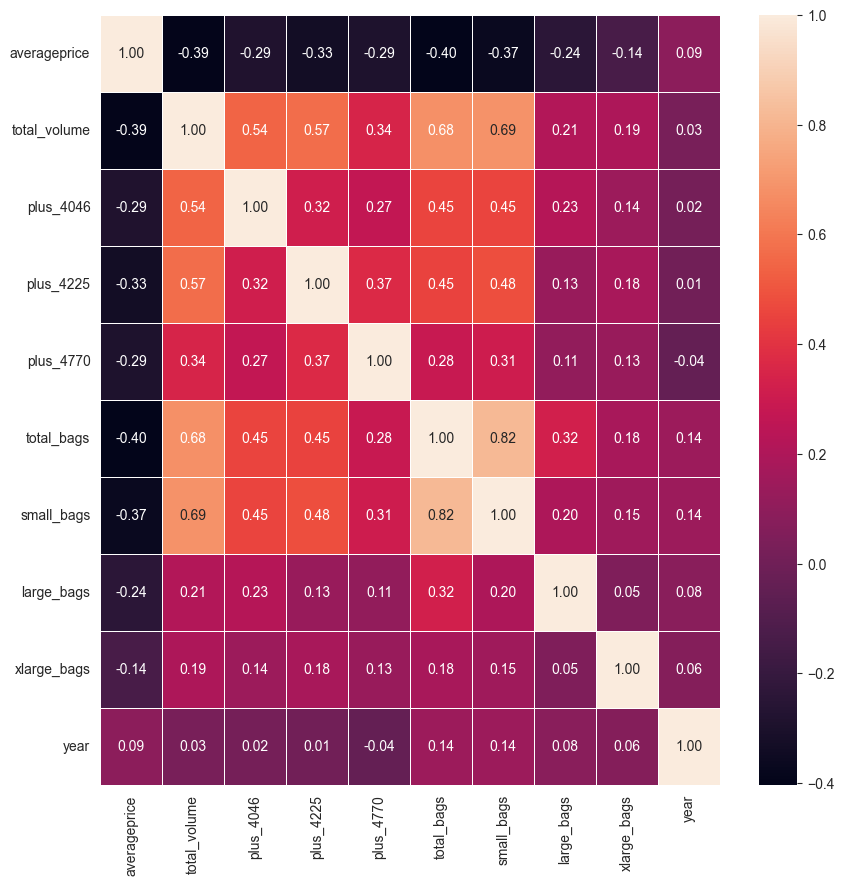

In [28]:
# Check correlation
plt.figure(figsize=(10,10))
sns.heatmap(df[num_cols].corr(), annot=True, linewidth=0.5, fmt='0.2f')

### `Split the Dataset`

In [29]:
X =df.drop(columns=['averageprice'], axis=1)
y = df['averageprice']

# Feature Selection
# Feature Selection is a techinque of finding out the features that contribute the most to our model i.e. the best predictors.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, shuffle=True, random_state=45)

### `Data Preprocessing`

In [30]:
# Pipeline
# Create separate pipelines for numeric and categorical columns
# For Numeric
num_pipeline = Pipeline(steps=[
                                ('selector', DataFrameSelector(num_cols1)),
                                ('scaler', StandardScaler())
])

# For Categorical
categ_pipeline = Pipeline(steps=[
                                ('selector', DataFrameSelector(categ_cols)),
                                ('OHe',OneHotEncoder())
                                ])


## all pipline
all_pipline = FeatureUnion(transformer_list=[
                ('numerical', num_pipeline),
                ('categorical', categ_pipeline)

])

X_train_final = all_pipline.fit_transform(X_train)
X_test_final = all_pipline.transform(X_test)

### `Build Models`

In [31]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_final,y_train)
print('train_score',lin_reg.score(X_train_final,y_train))
print('test_score',lin_reg.score(X_test_final,y_test))
y_pred_lin_reg = lin_reg.predict(X_test_final)
r2_lin_reg = r2_score(y_test,y_pred_lin_reg)
print('r2_score',r2_score(y_test,y_pred_lin_reg))
mae_lin_reg = mean_absolute_error(y_test,y_pred_lin_reg)
print('MAE',mean_absolute_error(y_test,y_pred_lin_reg))
mse_lin_reg = mean_squared_error(y_test,y_pred_lin_reg)
print('MSE',mean_squared_error(y_test,y_pred_lin_reg))
mapr_lin_reg = mean_absolute_percentage_error(y_test,y_pred_lin_reg)
print('MAPR',mean_absolute_percentage_error(y_test,y_pred_lin_reg))

train_score 0.5666446514339769
test_score 0.5602612679065685
r2_score 0.5602612679065685
MAE 0.20105874498428378
MSE 0.07149410004588783
MAPR 0.15441623755120773


In [32]:
lin_reg.intercept_

1.407201053178755

In [33]:
lin_reg.coef_

array([-0.03343698,  0.00366071, -0.00735812, -0.01081338, -0.02440219,
        0.00718024, -0.01484807,  0.00158013,  0.04280424, -0.21023356,
        0.21023356,  0.11927136, -0.05639882,  0.17221587, -0.08881315,
        0.15724688,  0.09418444, -0.02274533,  0.17287081,  0.16202694,
       -0.18103571, -0.1759978 , -0.3125253 , -0.14161951, -0.12542208,
        0.07363315, -0.07540393,  0.08657581,  0.40407042, -0.33243594,
       -0.0949185 ,  0.08531929, -0.00919978, -0.19482538, -0.13804873,
        0.05685018, -0.00389447, -0.21566431, -0.11314954,  0.31314678,
        0.20133454,  0.08076326,  0.10121091,  0.23912254, -0.15397208,
       -0.06867725,  0.02916187, -0.06302336,  0.14038051, -0.12965651,
       -0.19003735,  0.21702876,  0.00810666,  0.40162664,  0.07535427,
        0.00730993, -0.31497998, -0.02865843,  0.02392207,  0.01037113,
        0.05100166,  0.01082672, -0.05922684, -0.11914509, -0.08545821])

In [34]:
pred1 =pd.DataFrame({'y_test':y_test, 'y_pred':y_pred_lin_reg})
pred1.reset_index(drop=True,inplace=True)
pred1


,y_test,y_pred
0,0.79,1.052950
1,1.43,1.400218
2,2.26,1.689206
3,0.96,1.309680
4,1.73,1.016108
...,...,...
3645,1.10,1.344857
3646,1.74,1.505325
3647,1.24,1.464863
3648,1.02,1.080858


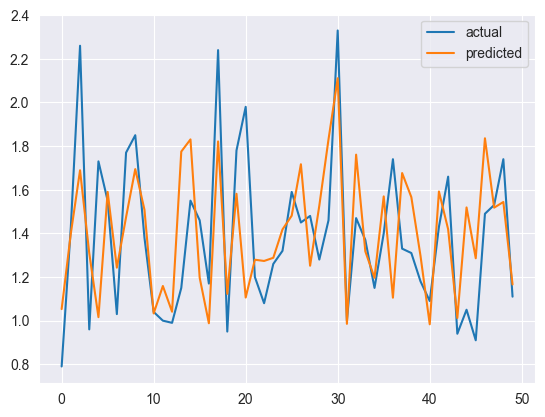

In [35]:
plt.plot(pred1[0:50])
plt.legend(['actual','predicted'])
plt.show()

In [36]:
xgb = XGBRegressor(n_estimators=100,max_depth=7)
xgb.fit(X_train_final,y_train)
print('train_score',xgb.score(X_train_final,y_train))
print('test_score',xgb.score(X_test_final,y_test))
y_pred_xgb = xgb.predict(X_test_final)
r2_xgb = r2_score(y_test,y_pred_xgb)
print('r2_score',r2_score(y_test,y_pred_xgb))
mae_xgb = mean_absolute_error(y_test,y_pred_xgb)
print('MAE',mean_absolute_error(y_test,y_pred_xgb))
mse_xgb = mean_squared_error(y_test,y_pred_xgb)
print('MSE',mean_squared_error(y_test,y_pred_xgb))
mapr_xgb = mean_absolute_percentage_error(y_test,y_pred_xgb)
print('MAPR',mean_absolute_percentage_error(y_test,y_pred_xgb))

train_score 0.9374367750377905
test_score 0.8363855822900351
r2_score 0.8363855822900351
MAE 0.11902461269848967
MSE 0.02660094436762178
MAPR 0.08907902023216462


In [37]:
pred2 =pd.DataFrame({'y_test':y_test, 'y_pred':y_pred_xgb})
pred2.reset_index(drop=True,inplace=True)
pred2

,y_test,y_pred
0,0.79,0.755079
1,1.43,1.528933
2,2.26,2.212214
3,0.96,1.037279
4,1.73,1.314797
...,...,...
3645,1.10,1.058167
3646,1.74,1.376111
3647,1.24,1.194612
3648,1.02,1.008366


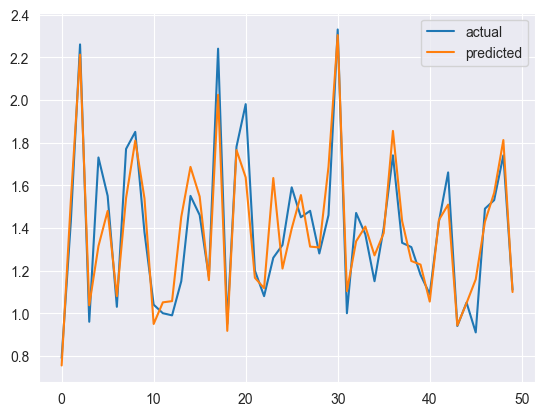

In [38]:
plt.plot(pred2[0:50])
plt.legend(['actual','predicted'])
plt.show()

In [39]:
forest_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features=0.6, random_state=42, n_jobs=-1 )
forest_reg.fit(X_train_final, y_train)
y_pred_forest =forest_reg.predict(X_test_final)
print('Accuracy of train model:',forest_reg.score(X_train_final, y_train))
print('Accuracy of test model',forest_reg.score(X_test_final,y_test))

r2_forest_reg=r2_score(y_test,y_pred_forest)
print('r2 score',r2_score(y_test,y_pred_forest))
MAE_forest_reg=mean_absolute_error(y_test,y_pred_forest)
print('MAE',mean_absolute_error(y_test,y_pred_forest))
MSE_forest_reg=mean_squared_error(y_test,y_pred_forest)
print('MSE',mean_squared_error(y_test,y_pred_forest))
MAPR_forest_reg=mean_absolute_percentage_error(y_test,y_pred_forest)
print('MAPR',mean_absolute_percentage_error(y_test,y_pred_forest))

Accuracy of train model: 0.7953041126713125
Accuracy of test model 0.7462226981605105
r2 score 0.7462226981605105
MAE 0.1535133936816924
MSE 0.04125990840223044
MAPR 0.11713577995412681


In [40]:
pred3 =pd.DataFrame({'y_test':y_test, 'y_pred':y_pred_forest})
pred3.reset_index(drop=True,inplace=True)
pred3

,y_test,y_pred
0,0.79,0.715843
1,1.43,1.452909
2,2.26,1.729865
3,0.96,1.102296
4,1.73,1.312038
...,...,...
3645,1.10,1.152289
3646,1.74,1.376784
3647,1.24,1.245725
3648,1.02,1.020835


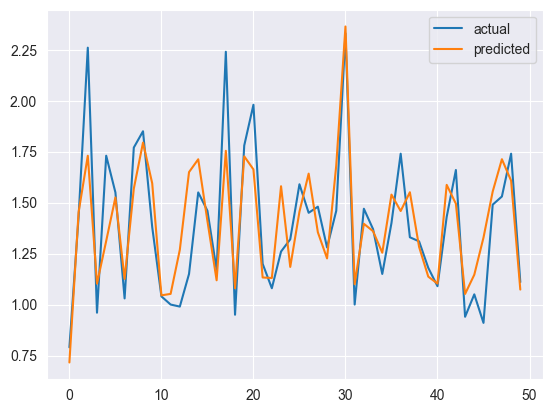

In [41]:
plt.plot(pred3[0:50])
plt.legend(['actual','predicted'])
plt.show()

In [42]:
dt_reg = DecisionTreeRegressor(criterion='friedman_mse', max_depth=10, max_features=.8, random_state=42)
dt_reg.fit(X_train_final,y_train)
y_pred_dt_reg = dt_reg.predict(X_test_final)
print('Accuracy of train model:',dt_reg.score(X_train_final, y_train))
print('accuracy of test model',dt_reg.score(X_test_final,y_test))
R2_DT=r2_score(y_test,y_pred_dt_reg)
print('r2 score',r2_score(y_test,y_pred_dt_reg))
MAE_DT=mean_absolute_error(y_test,y_pred_dt_reg)
print('MAE',mean_absolute_error(y_test,y_pred_dt_reg))
MSE_DT=mean_squared_error(y_test,y_pred_dt_reg)
print('MSE',mean_squared_error(y_test,y_pred_dt_reg))
MAPR_DT=mean_absolute_percentage_error(y_test,y_pred_dt_reg)
print('MAPR',mean_absolute_percentage_error(y_test,y_pred_dt_reg))

Accuracy of train model: 0.722740396790539
accuracy of test model 0.6544345762508568
r2 score 0.6544345762508568
MAE 0.17493669247170932
MSE 0.05618310868434393
MAPR 0.13246349646472283


In [43]:
pred4 =pd.DataFrame({'y_test':y_test, 'y_pred':y_pred_dt_reg})
pred4.reset_index(drop=True,inplace=True)
pred4

,y_test,y_pred
0,0.79,0.725000
1,1.43,1.366038
2,2.26,1.796096
3,0.96,1.029442
4,1.73,1.266819
...,...,...
3645,1.10,1.178889
3646,1.74,1.266819
3647,1.24,1.299583
3648,1.02,1.062319


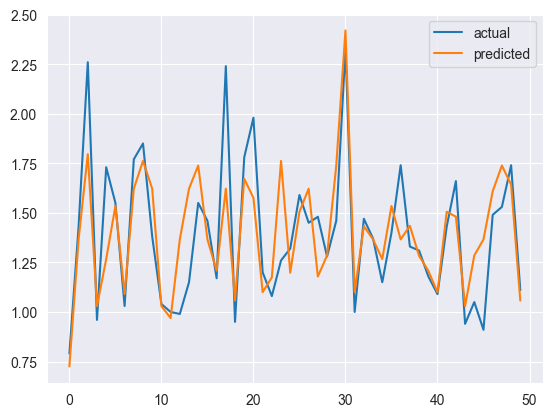

In [44]:
plt.plot(pred4[0:50])
plt.legend(['actual','predicted'])
plt.show()

### `Download the best Model`

In [45]:
## Download using joblib
joblib.dump(xgb,'Model_XGBoost.pkl')

['Model_XGBoost.pkl']

In [46]:
## load Model
model = joblib.load('Model_XGBoost.pkl')
model

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=7, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)